In [482]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import  GaussianNB


In [483]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()


In [484]:
df_num = pd.DataFrame(data.data, columns=data.feature_names)

df_num['target'] = data.target

## Preprecessing step

In [485]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [486]:
df_num.duplicated().sum()

np.int64(0)

<Axes: >

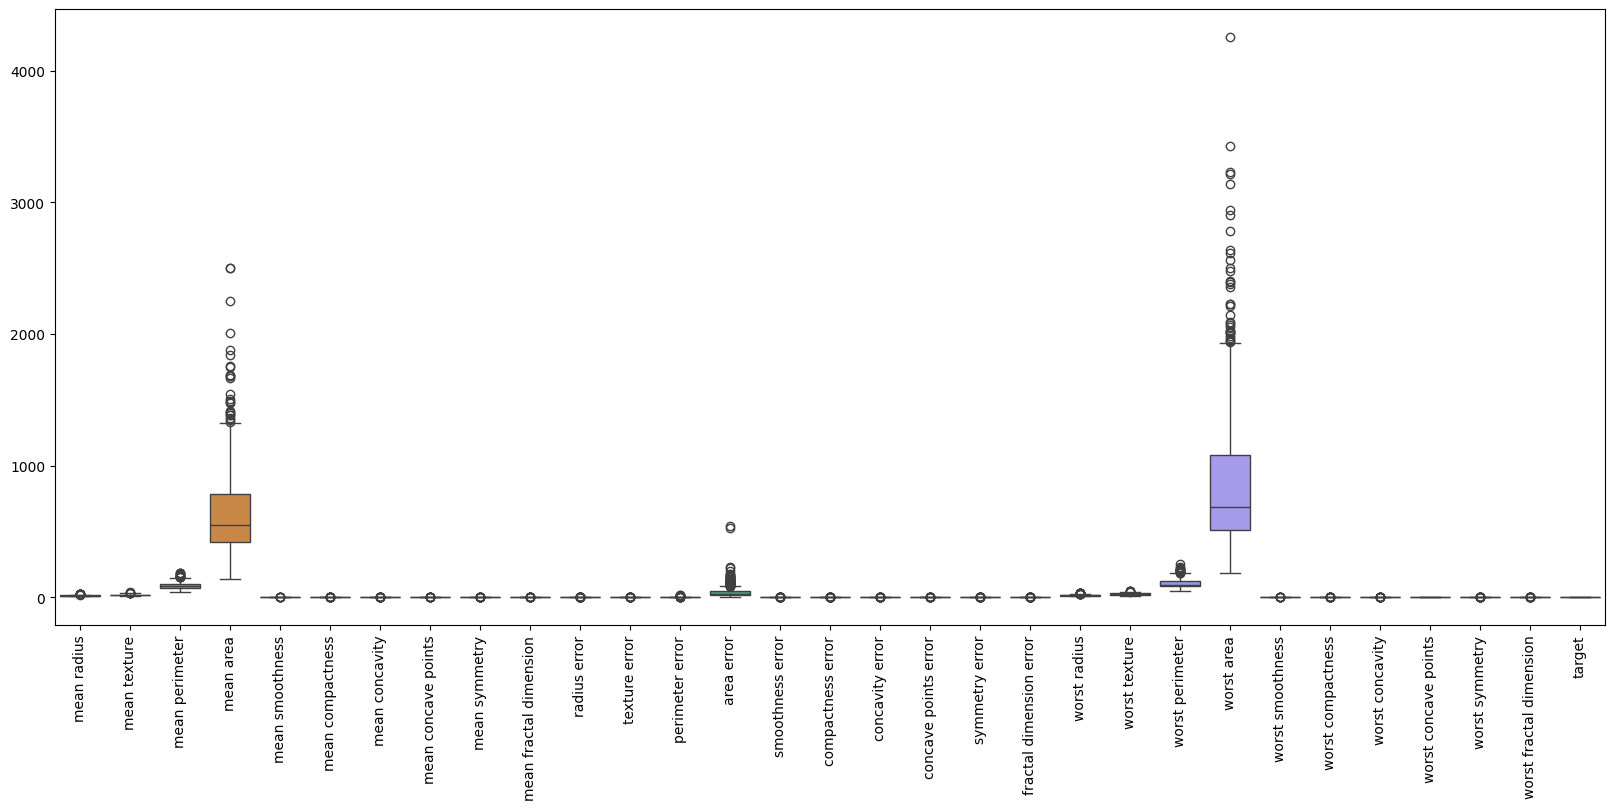

In [487]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,8))
plt.xticks(rotation = 90)

sns.boxplot(df_num)

In [488]:
X_num = df_num.drop("target" ,axis=1 )
y_num = df_num["target"]

In [489]:
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num, y_num, test_size=0.2, random_state=20)

In [490]:
y_test_num.head()

269    1
263    0
30     0
452    1
214    0
Name: target, dtype: int64

In [491]:
y_train_num = pd.DataFrame(y_train_num)

In [492]:
y_train_num["target"].value_counts()

target
1    291
0    164
Name: count, dtype: int64

In [493]:
smote = SMOTE(random_state=70)
X_train_smoted, y_train_smoted = smote.fit_resample(X_train_num, y_train_num)

In [494]:
y_train_smoted["target"].value_counts()

target
1    291
0    291
Name: count, dtype: int64

In [495]:
pt = PowerTransformer(method='yeo-johnson') 
X_train_transformed = pt.fit_transform(X_train_smoted)
X_test_transformed = pt.transform(X_test_num)

In [496]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_transformed)
X_test_scaled = scaler.transform(X_test_transformed)

## Experiment 0: Baseline

In [497]:
from sklearn.naive_bayes import  GaussianNB
gaussian_nb = GaussianNB()

### Evaluate the model using Accuracy, Classification Report

In [498]:
gaussian_nb.fit(X_train_scaled, y_train_smoted)

y_pred = gaussian_nb.predict(X_test_scaled)
print(f"Accuracy for baseline: {accuracy_score(y_test_num, y_pred):.2%}")
print(classification_report(y_test_num, y_pred))

Accuracy for baseline: 94.74%
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        48
           1       0.94      0.97      0.96        66

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.95       114
weighted avg       0.95      0.95      0.95       114



c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Experiment A: Feature Selection using Corr matrix

In [499]:
X_train_scaled = pd.DataFrame(X_train_scaled , columns=data.feature_names)

In [500]:
whole_processed_train_data = pd.concat([X_train_scaled, y_train_smoted], axis=1)

In [501]:
X_train_scaled

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-1.813691,0.460558,-1.814079,-1.808696,-1.331651,-1.074087,-0.844109,-1.594162,-2.468703,0.845618,...,-1.922109,0.288707,-1.750435,-1.930624,-1.182701,-0.505967,-0.501911,-1.605875,-1.027945,0.577881
1,2.494323,1.357423,2.529593,2.624560,0.876493,1.518477,2.110895,2.032012,0.918239,-1.080310,...,2.444137,0.785768,2.501249,2.563510,0.125623,0.994167,1.537061,1.886797,-0.451628,-0.585493
2,-0.185952,-0.816941,-0.232549,-0.192850,-0.303987,-0.751859,-1.264682,-1.018064,-0.734742,-0.020661,...,-0.110835,-1.044203,-0.200464,-0.099990,-0.303243,-0.795312,-0.924498,-0.600200,-0.127903,-0.312607
3,0.158879,0.138882,0.123745,0.149293,-0.065822,-0.480111,-0.283036,0.014090,-1.389367,-0.805942,...,-0.074685,0.363307,-0.123855,-0.076520,-0.532604,-0.964788,-0.604228,-0.371664,-1.044190,-1.319564
4,0.418492,0.922514,0.415816,0.428795,-0.988110,-0.096996,0.186681,0.129881,0.147625,-1.772653,...,0.105298,0.237945,0.129145,0.122117,-0.952761,-0.474498,-0.240567,-0.215126,-0.122247,-1.636281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,1.583567,0.682755,1.586487,1.545523,1.057232,1.423338,1.741301,1.810194,1.300072,0.299314,...,1.521744,0.306165,1.423158,1.518173,0.298072,1.225376,1.591649,1.471752,1.089025,0.605264
578,0.601698,-0.027045,0.531529,0.587432,-1.466541,-0.535372,-0.614957,-0.593675,0.106318,-1.552965,...,0.542660,-0.046367,0.535570,0.485531,-1.245434,0.411002,0.040532,-0.332500,2.037454,-0.261699
579,-0.139379,-0.891468,-0.105291,-0.148972,0.442695,0.457512,-0.063103,0.058213,-0.382593,0.494351,...,0.039941,-0.870636,0.063955,-0.005853,0.458568,0.600632,0.048122,0.178152,-0.352640,0.872204
580,1.178093,1.230091,1.228496,1.193786,-0.365584,1.243889,0.757916,0.988491,0.418207,0.000329,...,1.382764,1.336509,1.447520,1.400091,0.208824,1.352974,0.735905,1.041969,0.540572,0.946715


In [502]:
whole_processed_train_data

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,-1.813691,0.460558,-1.814079,-1.808696,-1.331651,-1.074087,-0.844109,-1.594162,-2.468703,0.845618,...,0.288707,-1.750435,-1.930624,-1.182701,-0.505967,-0.501911,-1.605875,-1.027945,0.577881,1
1,2.494323,1.357423,2.529593,2.624560,0.876493,1.518477,2.110895,2.032012,0.918239,-1.080310,...,0.785768,2.501249,2.563510,0.125623,0.994167,1.537061,1.886797,-0.451628,-0.585493,0
2,-0.185952,-0.816941,-0.232549,-0.192850,-0.303987,-0.751859,-1.264682,-1.018064,-0.734742,-0.020661,...,-1.044203,-0.200464,-0.099990,-0.303243,-0.795312,-0.924498,-0.600200,-0.127903,-0.312607,1
3,0.158879,0.138882,0.123745,0.149293,-0.065822,-0.480111,-0.283036,0.014090,-1.389367,-0.805942,...,0.363307,-0.123855,-0.076520,-0.532604,-0.964788,-0.604228,-0.371664,-1.044190,-1.319564,1
4,0.418492,0.922514,0.415816,0.428795,-0.988110,-0.096996,0.186681,0.129881,0.147625,-1.772653,...,0.237945,0.129145,0.122117,-0.952761,-0.474498,-0.240567,-0.215126,-0.122247,-1.636281,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,1.583567,0.682755,1.586487,1.545523,1.057232,1.423338,1.741301,1.810194,1.300072,0.299314,...,0.306165,1.423158,1.518173,0.298072,1.225376,1.591649,1.471752,1.089025,0.605264,0
578,0.601698,-0.027045,0.531529,0.587432,-1.466541,-0.535372,-0.614957,-0.593675,0.106318,-1.552965,...,-0.046367,0.535570,0.485531,-1.245434,0.411002,0.040532,-0.332500,2.037454,-0.261699,0
579,-0.139379,-0.891468,-0.105291,-0.148972,0.442695,0.457512,-0.063103,0.058213,-0.382593,0.494351,...,-0.870636,0.063955,-0.005853,0.458568,0.600632,0.048122,0.178152,-0.352640,0.872204,0
580,1.178093,1.230091,1.228496,1.193786,-0.365584,1.243889,0.757916,0.988491,0.418207,0.000329,...,1.336509,1.447520,1.400091,0.208824,1.352974,0.735905,1.041969,0.540572,0.946715,0


In [503]:
corr_matrix = whole_processed_train_data.corr()

In [504]:
corr_matrix

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.381098,0.998220,0.999634,0.170183,0.551689,0.700736,0.817341,0.185663,-0.327049,...,0.320229,0.973433,0.976958,0.109090,0.472312,0.571335,0.753257,0.177681,0.037803,-0.715554
mean texture,0.381098,1.000000,0.390132,0.383010,0.071353,0.352425,0.425542,0.398111,0.134460,-0.007382,...,0.919336,0.421348,0.414504,0.156813,0.368283,0.399322,0.396075,0.160440,0.204680,-0.503030
mean perimeter,0.998220,0.390132,1.000000,0.997735,0.205545,0.596530,0.735412,0.842992,0.216512,-0.280902,...,0.332654,0.978683,0.977782,0.140561,0.513592,0.607287,0.781081,0.201779,0.081174,-0.731731
mean area,0.999634,0.383010,0.997735,1.000000,0.163619,0.545485,0.699136,0.814914,0.180603,-0.333577,...,0.322392,0.974545,0.979114,0.105320,0.467689,0.569569,0.750280,0.173598,0.033554,-0.717000
mean smoothness,0.170183,0.071353,0.205545,0.163619,1.000000,0.674582,0.533445,0.562159,0.565504,0.600771,...,0.139084,0.245905,0.214418,0.808791,0.501607,0.451287,0.519427,0.406791,0.515220,-0.396494
mean compactness,0.551689,0.352425,0.596530,0.545485,0.674582,1.000000,0.911860,0.864101,0.592633,0.505753,...,0.371950,0.642441,0.587470,0.594415,0.901949,0.858486,0.866214,0.502731,0.695258,-0.670879
mean concavity,0.700736,0.425542,0.735412,0.699136,0.533445,0.911860,1.000000,0.941256,0.497789,0.282601,...,0.422639,0.766140,0.728289,0.487118,0.828569,0.920130,0.916991,0.426721,0.548120,-0.768092
mean concave points,0.817341,0.398111,0.842992,0.814914,0.562159,0.864101,0.941256,1.000000,0.484313,0.145635,...,0.385867,0.862162,0.836250,0.470475,0.737906,0.805573,0.940672,0.396691,0.413031,-0.811159
mean symmetry,0.185663,0.134460,0.216512,0.180603,0.565504,0.592633,0.497789,0.484313,1.000000,0.432346,...,0.170318,0.257920,0.223592,0.450772,0.487899,0.446727,0.474594,0.737374,0.433812,-0.376696
mean fractal dimension,-0.327049,-0.007382,-0.280902,-0.333577,0.600771,0.505753,0.282601,0.145635,0.432346,1.000000,...,0.065871,-0.221296,-0.276049,0.528747,0.442540,0.313836,0.187649,0.326753,0.778575,-0.015265


In [505]:
target_corr = corr_matrix["target"]

relevant_features = target_corr[(abs(target_corr) >= 0.77) & (abs(target_corr) < 1)]

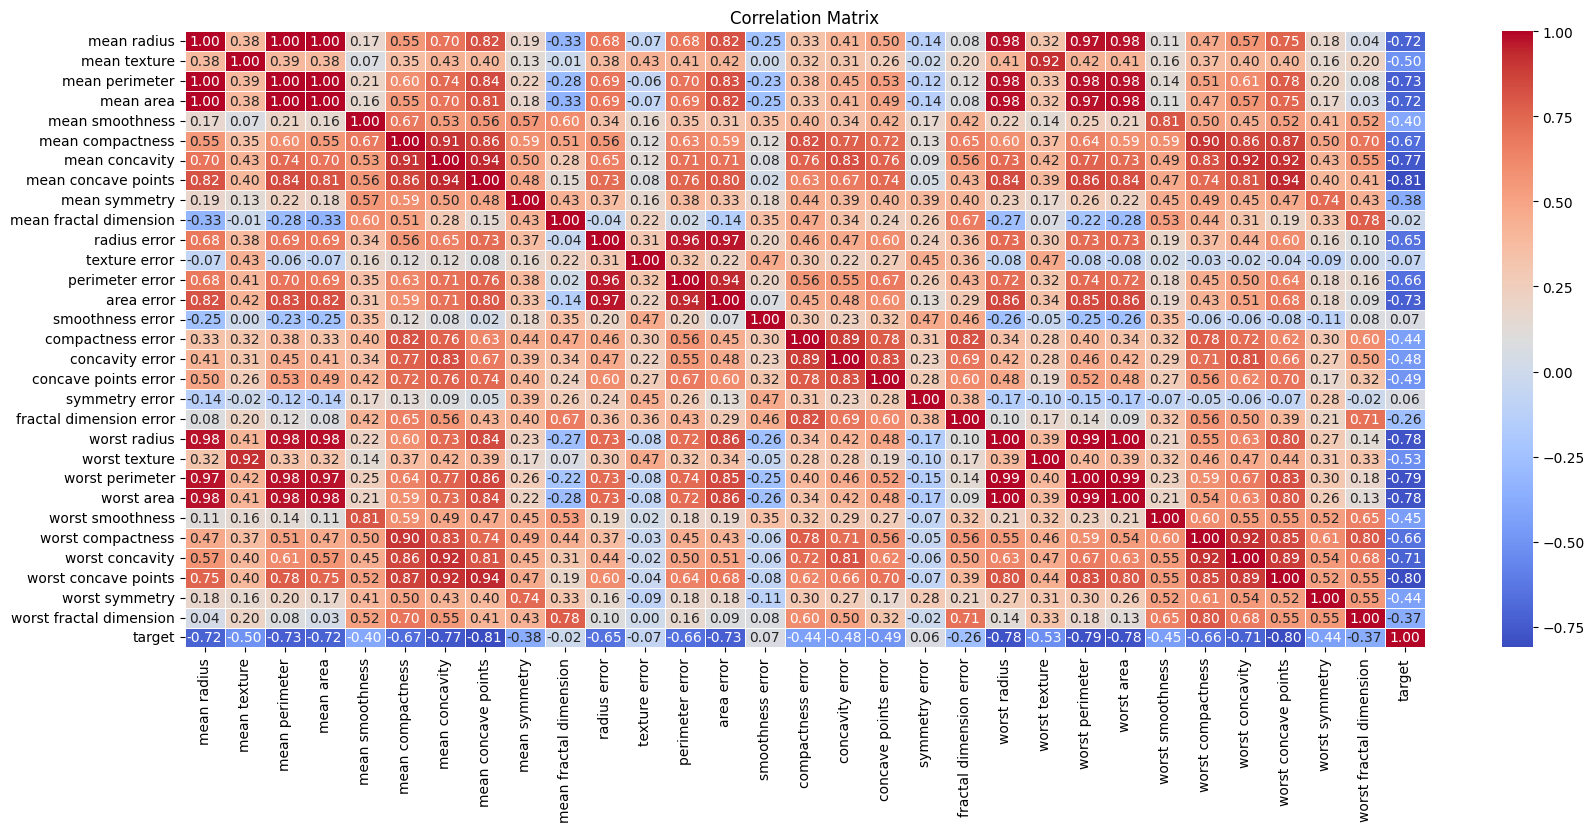

In [506]:
plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [507]:
train_selected_featuers = whole_processed_train_data[relevant_features.index]

In [508]:
train_selected_featuers

,mean concave points,worst radius,worst perimeter,worst area,worst concave points
0,-1.594162,-1.922109,-1.750435,-1.930624,-1.605875
1,2.032012,2.444137,2.501249,2.563510,1.886797
2,-1.018064,-0.110835,-0.200464,-0.099990,-0.600200
3,0.014090,-0.074685,-0.123855,-0.076520,-0.371664
4,0.129881,0.105298,0.129145,0.122117,-0.215126
...,...,...,...,...,...
577,1.810194,1.521744,1.423158,1.518173,1.471752
578,-0.593675,0.542660,0.535570,0.485531,-0.332500
579,0.058213,0.039941,0.063955,-0.005853,0.178152
580,0.988491,1.382764,1.447520,1.400091,1.041969


In [509]:
X_test_scaled = pd.DataFrame(X_test_scaled , columns=data.feature_names )


In [510]:
test_selected_featuers = X_test_scaled[relevant_features.index]

In [511]:
test_selected_featuers

,mean concave points,worst radius,worst perimeter,worst area,worst concave points
0,-0.650273,-1.267708,-1.219110,-1.297718,-0.616575
1,-0.657360,0.320325,0.242528,0.331439,-0.621618
2,1.529257,1.165923,1.261595,1.196187,0.848558
3,-0.992669,-0.823968,-0.827609,-0.822097,-0.852622
4,0.415384,0.109486,0.216813,-0.014536,0.741949
...,...,...,...,...,...
109,1.198555,0.847954,0.774652,0.811309,1.158702
110,0.098954,-1.791972,-1.610293,-1.936197,-0.359315
111,-1.444844,-0.666599,-0.765570,-0.685892,-1.181800
112,0.771664,-0.304154,0.032161,-0.286288,1.340972


### Evaluate the model using Accuracy, Classification Report,

In [512]:
gaussian_nb_selected_featuers = GaussianNB()

gaussian_nb_selected_featuers.fit(train_selected_featuers, y_train_smoted)

y_pred_selected_featuers = gaussian_nb_selected_featuers.predict(test_selected_featuers)
print(f"Accuracy for selected featuers: {accuracy_score(y_test_num, y_pred_selected_featuers):.2%}")
print(classification_report(y_test_num, y_pred_selected_featuers))

Accuracy for selected featuers: 97.37%
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        48
           1       0.97      0.98      0.98        66

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### Compare the results with the baseline.

Text(0.5, 1.0, 'Model Accuracy Comparison')

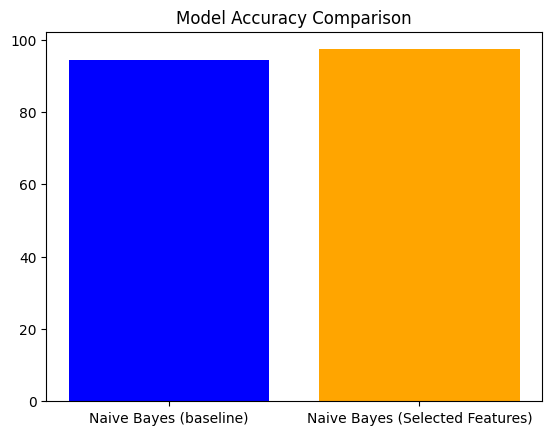

In [523]:
models = ['Naive Bayes (baseline)', 'Naive Bayes (Selected Features)']

accuracy_list = [94.4 , 97.3]

plt.bar(models, accuracy_list, color=['blue', 'orange'])
plt.title('Model Accuracy Comparison')

## Experiment B: PCA

In [513]:
from PCA import pca

n_components = 5
X_train_pca, principal_components = pca(X_train_scaled, n_components)
X_test_pca = (X_test_scaled - np.mean(X_test_scaled, axis=0)) @ principal_components  



In [ ]:
Gaussian_nb_PCA = GaussianNB()
Gaussian_nb_PCA.fit(X_train_pca, y_train_smoted)


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,priors,None
,var_smoothing,1e-09


### Evaluate the model using Accuracy, Classification Report,

In [517]:
y_pred_PCA = Gaussian_nb_PCA.predict(X_test_pca)

accuracy = accuracy_score(y_test_num, y_pred)
print(f"Accuracy for PCA: {accuracy}")
print("Classification Report:")
print(classification_report(y_test_num, y_pred))


Accuracy for PCA: 0.9473684210526315
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        48
           1       0.94      0.97      0.96        66

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.95       114
weighted avg       0.95      0.95      0.95       114



### Compare the results with the baseline.

Text(0.5, 1.0, 'Model Accuracy Comparison')

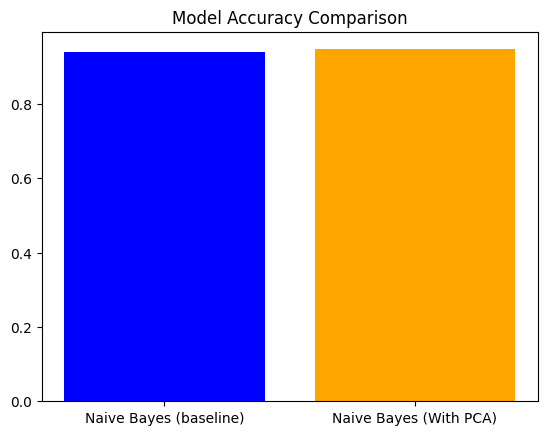

In [522]:
models = ['Naive Bayes (baseline)', 'Naive Bayes (With PCA)']
accuracy_list = [0.94, 0.947]
plt.bar(models, accuracy_list, color=['blue', 'orange'])
plt.title('Model Accuracy Comparison')


### Experiment with multiple values of k and report the best-performing value.

In [518]:
best_accuracy = 0
best_k = 0
accuracies = []
for i in range(3 ,11 ,2):
    x_train_PCA , PC = pca(X_train_scaled, n_components=i)
    x_test_PCA = (X_test_scaled - np.mean(X_test_scaled, axis=0)) @ PC
    Gaussian_nb_PCA = GaussianNB()
    Gaussian_nb_PCA.fit(x_train_PCA, y_train_smoted)
    y_pred_PCA = Gaussian_nb_PCA.predict(x_test_PCA)
    accuracy = accuracy_score(y_test_num, y_pred_PCA)
    accuracies.append(accuracy)
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = i
        
print(f"Best number of components (k): {best_k} with accuracy: {best_accuracy}")



Best number of components (k): 5 with accuracy: 0.956140350877193


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConve

Text(0, 0.5, 'Accuracy')

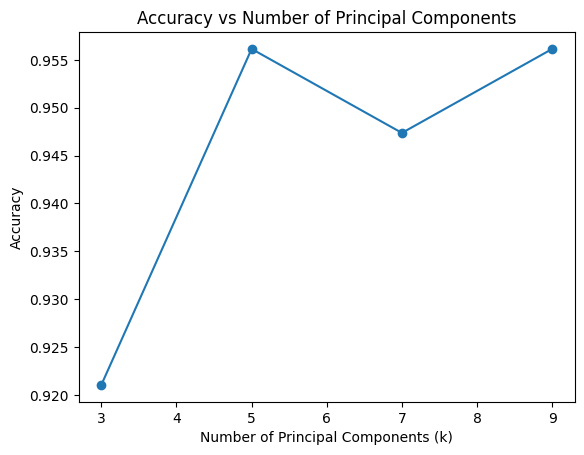

In [521]:

plt.plot(range(3,11,2), accuracies, marker='o')
plt.title('Accuracy vs Number of Principal Components')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Accuracy')
